<a href="https://colab.research.google.com/github/mohits2508sse-lab/ML-LAB-EXPERIMENT/blob/main/EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best K: 3
Maximum Accuracy: 100.0 %
Predicted Class: versicolor


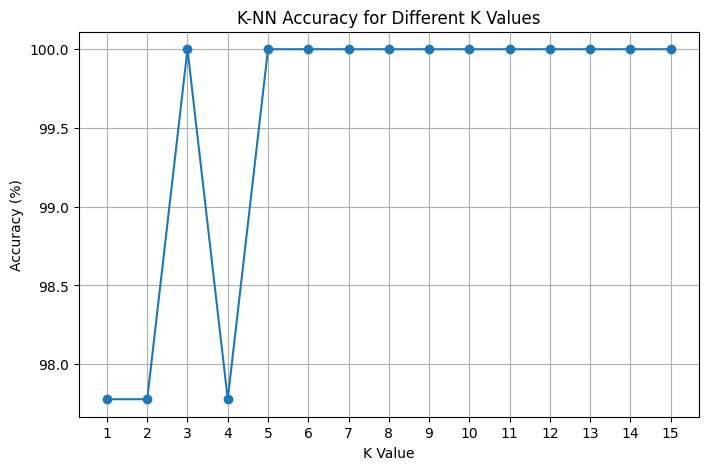

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred) * 100)

best_k = k_values[accuracies.index(max(accuracies))]

print("Best K:", best_k)
print("Maximum Accuracy:", round(max(accuracies), 2), "%")

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

sample = X_test[0].reshape(1, -1)

prediction = final_knn.predict(sample)

print("Predicted Class:", iris.target_names[prediction[0]])

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("K-NN Accuracy for Different K Values")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.xticks(k_values)
plt.grid(True)
plt.show()